In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML
from IPython.display import Video
from scipy.optimize import minimize

from matplotlib.animation import FuncAnimation

working in a 10x10 grid


In [2]:
# choreographies
def straight_line(start, finish, tf):
  """returns a straight line parameterized to x, y with x' y' all callable"""
  x = lambda t: start[0] + t * (finish[0] - start[0])/tf
  y = lambda t: start[1] + t * (finish[1] - start[1])/tf
  xp = lambda t: (finish[0] - start[0])/tf
  yp = lambda t: (finish[1] - start[1])/tf
  return np.array([x, y, xp, yp])

def circle(center, radius):
  """returns a circle parameterized to x, y with x' y' all callable"""
  x = lambda t: center[0] + radius * np.cos(t)
  y = lambda t: center[1] + radius * np.sin(t)
  xp = lambda t: -radius * np.sin(t)
  yp = lambda t: radius * np.cos(t)
  return np.array([x, y, xp, yp])


def back_and_forth(middle, A, B, a, b, delta):
  """returns a back and forth parameterized to x, y with x' y' all callable"""
  x = lambda t: middle[0] + A * np.sin(a * t + delta)
  y = lambda t: middle[1] + B * np.cos(b * t)
  xp = lambda t: A * a * np.cos(a * t + delta)
  yp = lambda t: -B * b * np.sin(b * t)

  return np.array([x, y, xp, yp])



def curliques(a: float, b:float):
  """returns a random wandering path parameterized to x, y with x' y' all callable
      a in [1.5, 4.5]
      b in [1.0, 3.0]
  """
  x = lambda t: 5 + 4.5*np.sin(a*t)*np.cos(b*t)
  y = lambda t: 5 + 4.5*np.cos(a*t)*np.sin(b*t)
  xp = lambda t: 4.5*a*np.cos(a*t)*np.cos(b*t) - 4.5*a*np.sin(a*t)*np.sin(b*t)
  yp = lambda t: 4.5*b*np.sin(a*t)*np.cos(b*t) - 4.5*b*np.cos(a*t)*np.sin(b*t)
  return np.array([x, y, xp, yp])

def show_choreo(choreography):
  x = choreography[0]
  y = choreography[1]
  t_range = np.linspace(0, 10, 100)
  plt.plot(x(t_range), y(t_range))
  plt.show()

In [3]:
def cost_function(x, choreography_state, other_choreography_state=None):
  """instantaneous cost"""
  ALPHA = 1 # weighting parameter
  BETA = 1
  cost = 0
  cost += np.sum(BETA*(x-choreography_state)**2)
  if other_choreography_state is not None:
    x_sub = x[:2]
    cost += np.sum(ALPHA * np.exp((-(x_sub-other_choreography_state)**2)/2))
  return cost


In [4]:
# simulation run
def simulation(choreography, tf, t_steps, filename1, filename2, other_choreography = None):
  """
  inputs:
  choreography
  end time
  number of other objects to model for // their choreography

  outputs:
  graph of the path
  U at each time step
  optimal path

  """
  t_evol = np.linspace(0, tf, t_steps)
  dt = t_evol[1]-t_evol[0]
  x, y, xp, yp = choreography
  H = np.array([[0, 0, dt, 0], [0, 0, 0, dt], [0, 0, 0, 0], [0, 0, 0, 0]])
  G = np.array([[0, 0], [0, 0], [dt, 0], [0, dt]])
  def _evolution(u_flat):
    # initial state
    u = u_flat.reshape(2, t_steps)
    x_vec = np.array([x(0), y(0), xp(0), yp(0)])
    cost = 0

    for i in range(t_steps):
        # calculate cost of that state
        if other_choreography is not None:
          oc_x = other_choreography[0]
          oc_y = other_choreography[1]
          other_choreography_state = np.array([oc_x(t_evol[i]), oc_y(t_evol[i])])
          choreography_state = np.array([x(t_evol[i]), y(t_evol[i]), xp(t_evol[i]), yp(t_evol[i])])
        else:
          choreography_state = np.array([x(t_evol[i]), y(t_evol[i]), xp(t_evol[i]), yp(t_evol[i])])
          other_choreography_state = None

        cost += cost_function(x_vec, choreography_state, other_choreography_state)

        # evolve to next time step
        x_new = x_vec + H @ x_vec + G@u[:, i]
        x_vec = x_new

    return cost


  # minimize the cost of the above
  u_guess = np.ones(2*t_steps)
  # return optimal control progression
  optimal_u = minimize(_evolution, u_guess).x.reshape(2, t_steps)

  # re run through the evolution to show the states
  optimal_path = np.zeros((4, t_steps))
  x_vec = np.array([x(0), y(0), xp(0), yp(0)])

  for i in range(t_steps):
    x_new = x_vec + H @ x_vec + G@optimal_u[:, i]
    x_vec = x_new
    optimal_path[:, i] = x_vec

  # plot the optimal path
  plt.plot(optimal_path[0, :], optimal_path[1, :], label='optimal path')
  # plot the choreography in a differenc color
  plt.plot(choreography[0](t_evol), choreography[1](t_evol), 'r', label='choreography')
  if other_choreography is not None:
    plt.plot(other_choreography[0](t_evol), other_choreography[1](t_evol), 'g', label='other choreography')
  plt.legend()
  plt.title("path versus choreography")
  plt.savefig(filename1)
  plt.show()


  # plot the optimal control
  plt.plot(optimal_u[0, :], label="optimal x acceleration")
  plt.plot(optimal_u[1, :], label="optimal y acceleration")
  plt.legend()
  plt.title("optimal control")
  plt.savefig(filename2)
  plt.show()


  return optimal_u, optimal_path

In [5]:
# animation using simulation
def animate_choreography(choreography, tf, t_steps, ani_title, other_choreography=None):
    """
    Animates a trajectory with velocity arrows.

    inputs:
        choreography: array of callables [x(t), y(t), xp(t), yp(t)]
        tf: final time
        t_steps: number of time steps
        other_choreography: optional second trajectory
    """

    t_evol = np.linspace(0, tf, t_steps)
    dt = t_evol[1] - t_evol[0]

    x, y, xp, yp = choreography

    if other_choreography is not None:
        x_o, y_o, xp_o, yp_o = other_choreography

    # Precompute trajectory
    X = np.array([x(t) for t in t_evol])
    Y = np.array([y(t) for t in t_evol])
    VX = np.array([xp(t) for t in t_evol])
    VY = np.array([yp(t) for t in t_evol])

    if other_choreography is not None:
        Xo = np.array([x_o(t) for t in t_evol])
        Yo = np.array([y_o(t) for t in t_evol])
        VXo = np.array([xp_o(t) for t in t_evol])
        VYo = np.array([yp_o(t) for t in t_evol])

    # Set up plot
    fig, ax = plt.subplots()
    ax.set_aspect('equal')

    # Set bounds
    all_x = X if other_choreography is None else np.concatenate([X, Xo])
    all_y = Y if other_choreography is None else np.concatenate([Y, Yo])
    ax.set_xlim(np.min(all_x) - 1, np.max(all_x) + 1)
    ax.set_ylim(np.min(all_y) - 1, np.max(all_y) + 1)

    # Main trajectory
    path_line, = ax.plot([], [], lw=2)
    point, = ax.plot([], [], 'o')

    # Velocity arrow
    quiver = ax.quiver([], [], [], [], angles='xy', scale_units='xy', scale=1)

    # Optional second trajectory
    if other_choreography is not None:
        path_line_o, = ax.plot([], [], lw=2, linestyle='--')
        point_o, = ax.plot([], [], 'o')
        quiver_o = ax.quiver([], [], [], [], angles='xy', scale_units='xy', scale=1)

    def init():
        path_line.set_data([], [])
        point.set_data([], [])
        return (path_line, point, quiver)

    def update(frame):
        # Update main trajectory
        path_line.set_data(X[:frame], Y[:frame])
        point.set_data([X[frame]], [Y[frame]])

        # Update velocity arrow
        quiver.set_offsets([X[frame], Y[frame]])
        quiver.set_UVC(VX[frame], VY[frame])

        artists = [path_line, point, quiver]

        # Update second trajectory if exists
        if other_choreography is not None:
            path_line_o.set_data(Xo[:frame], Yo[:frame])
            point_o.set_data([Xo[frame]], [Yo[frame]])
            quiver_o.set_offsets([Xo[frame], Yo[frame]])
            quiver_o.set_UVC(VXo[frame], VYo[frame])

            artists += [path_line_o, point_o, quiver_o]

        return artists

    anim = FuncAnimation(
        fig,
        update,
        frames=t_steps,
        init_func=init,
        blit=True,
        interval=50
    )

    if ani_title is not None:
      anim.save(ani_title, writer='ffmpeg', fps=30)
    return anim


In [6]:
# animate the optimal control
def animate_optimal_control(
    choreography, tf, t_steps, ani_title,
    optimal_u, optimal_path,
    other_choreography=None
):
    """
    Animate:
    - choreography (reference)
    - optimal path (controlled)
    - optional other choreography
    with velocity arrows
    """

    t_evol = np.linspace(0, tf, t_steps)

    # unpack choreography
    x, y, xp, yp = choreography

    # evaluate choreography
    X = np.array([x(t) for t in t_evol])
    Y = np.array([y(t) for t in t_evol])
    VX = np.array([xp(t) for t in t_evol])
    VY = np.array([yp(t) for t in t_evol])

    # optimal path (already discrete)
    X_opt = optimal_path[0, :]
    Y_opt = optimal_path[1, :]
    VX_opt = optimal_path[2, :]
    VY_opt = optimal_path[3, :]

    # other choreography
    if other_choreography is not None:
        xo, yo, xpo, ypo = other_choreography
        Xo = np.array([xo(t) for t in t_evol])
        Yo = np.array([yo(t) for t in t_evol])
        VXo = np.array([xpo(t) for t in t_evol])
        VYo = np.array([ypo(t) for t in t_evol])

    # plot setup
    fig, ax = plt.subplots()
    ax.set_aspect('equal')

    # bounds
    all_x = [X, X_opt]
    all_y = [Y, Y_opt]
    if other_choreography is not None:
        all_x.append(Xo)
        all_y.append(Yo)

    all_x = np.concatenate(all_x)
    all_y = np.concatenate(all_y)

    ax.set_xlim(np.min(all_x) - 1, np.max(all_x) + 1)
    ax.set_ylim(np.min(all_y) - 1, np.max(all_y) + 1)

    # lines
    choreo_line, = ax.plot([], [], 'r', label='choreography')
    opt_line, = ax.plot([], [], 'b', label='optimal path')

    choreo_point, = ax.plot([], [], 'ro')
    opt_point, = ax.plot([], [], 'bo')

    # velocity arrows
    q_choreo = ax.quiver([], [], [], [], scale_units='xy', scale=1)
    q_opt = ax.quiver([], [], [], [], scale_units='xy', scale=1)

    if other_choreography is not None:
        other_line, = ax.plot([], [], 'g', label='other choreography')
        other_point, = ax.plot([], [], 'go')
        q_other = ax.quiver([], [], [], [], scale_units='xy', scale=1)

    ax.legend()

    def init():
        choreo_line.set_data([], [])
        opt_line.set_data([], [])
        return (choreo_line, opt_line)

    def update(frame):
        artists = []

        # --- choreography ---
        choreo_line.set_data(X[:frame], Y[:frame])
        choreo_point.set_data([X[frame]], [Y[frame]])
        q_choreo.set_offsets([X[frame], Y[frame]])
        q_choreo.set_UVC(VX[frame], VY[frame])

        artists += [choreo_line, choreo_point, q_choreo]

        # --- optimal path ---
        opt_line.set_data(X_opt[:frame], Y_opt[:frame])
        opt_point.set_data([X_opt[frame]], [Y_opt[frame]])
        q_opt.set_offsets([X_opt[frame], Y_opt[frame]])
        q_opt.set_UVC(VX_opt[frame], VY_opt[frame])

        artists += [opt_line, opt_point, q_opt]

        # --- other choreography ---
        if other_choreography is not None:
            other_line.set_data(Xo[:frame], Yo[:frame])
            other_point.set_data([Xo[frame]], [Yo[frame]])
            q_other.set_offsets([Xo[frame], Yo[frame]])
            q_other.set_UVC(VXo[frame], VYo[frame])

            artists += [other_line, other_point, q_other]

        return artists

    anim = FuncAnimation(
        fig,
        update,
        frames=t_steps,
        init_func=init,
        blit=True,
        interval=50
    )

    plt.show()

    # save animation
    if ani_title is not None:
        anim.save(ani_title, writer='ffmpeg', fps=30)

    return anim

In [7]:
# animate_choreography(straight_line((0, 0), (10, 10), 10), 10, 100, "straight_line.mp4")
# Video("straight_line.mp4", width=640, embed=True)
curly_choreo = curliques(a=3.0, b=2.0)
cc2 = curliques(a=2.3, b=1.7)   # dense curlicues (irrational-ish ratio)
# animate_choreography(curly_choreo, 10, 100, "curliques.mp4", other_choreography=cc2)
# Video("curliques.mp4", width=640, embed=True)

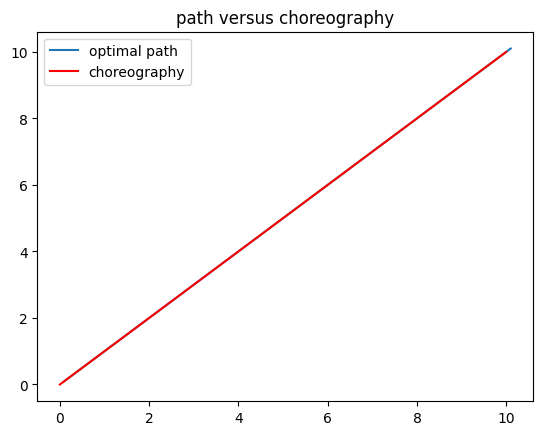

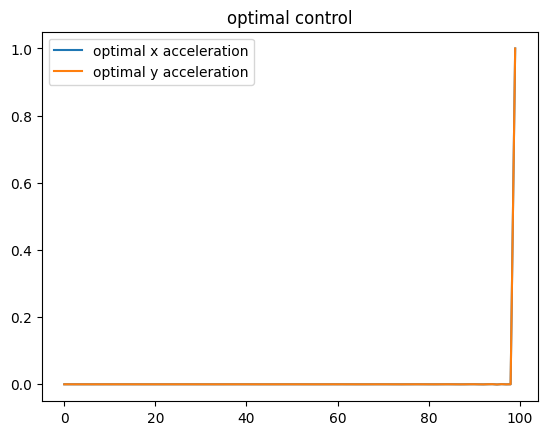

In [8]:
# one couple in a straight line
tf = 10
t_steps = 100
choreography = straight_line((0, 0), (10, 10), tf)
opmtimal_u, optimal_path = simulation(choreography, tf, t_steps, filename1="straight_linepath.jpg", filename2="straight_lineu.jpg")
#

In [9]:
# one couple complex choreo

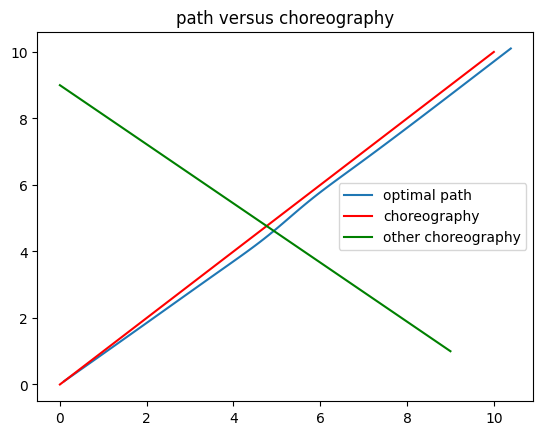

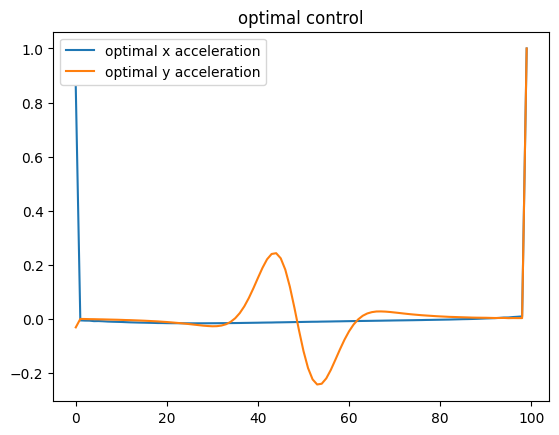

In [10]:
# two couples simple straight-line choreo
choreography1 = straight_line((0, 0), (10, 10), tf)
choreography2 = straight_line((0, 9), (9, 1), tf)
tf = 10
t_steps = 100
optimal_u, optimal_path = simulation(choreography1, tf, t_steps, filename1="twocouplestraightlinepath.jpg", filename2="twocouplestraightlineu.jpg", other_choreography=choreography2) #choreography, tf, t_steps, other_choreography = None

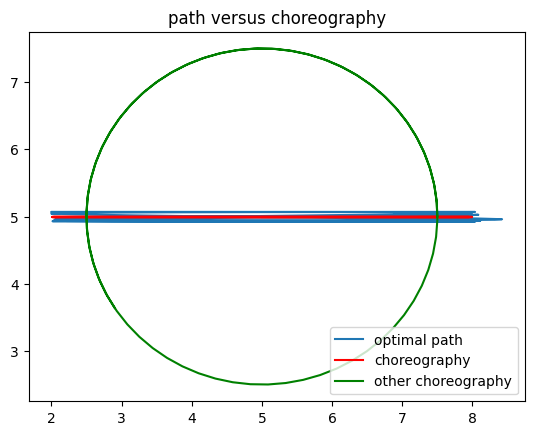

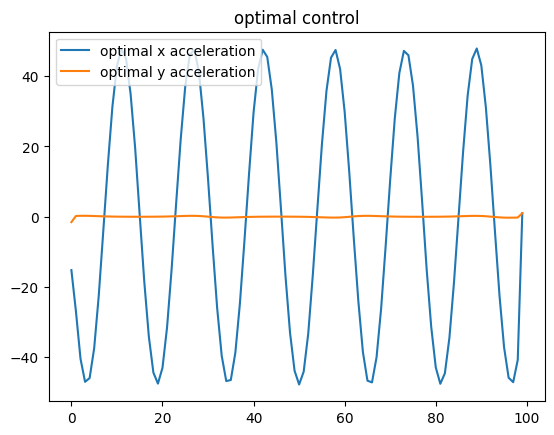

In [11]:
# two couples, one oscillating, one doing a circle
choreography1 = back_and_forth((5,5), A=3, B=0, a=4, b=0, delta=0)
choreography2 = circle((5, 5), 2.5)
tf = 10
t_steps = 100
optimal_u, optimal_path = simulation(choreography1, tf, t_steps, filename1="oscillatingcirclepath.jpg", filename2="oscillatingcircleu.jpg", other_choreography=choreography2)

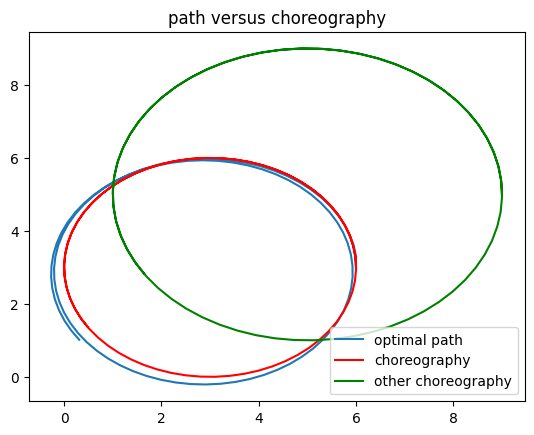

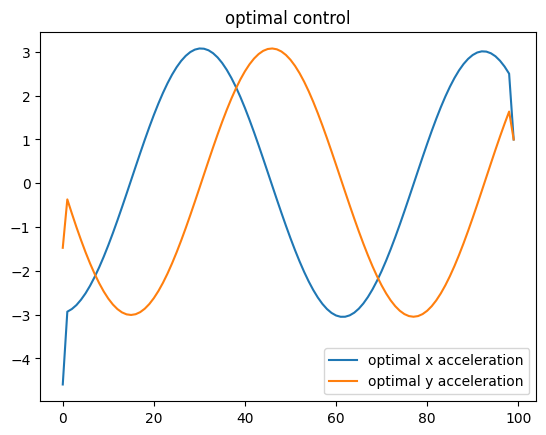

In [12]:
# two couples, intersecting circles
choreography1 = circle((3, 3), 3)
choreography2 = circle((5, 5), 4)
tf = 10
t_steps = 100
optimal_u, optimal_path = simulation(choreography1, tf, t_steps, filename1="twocirclespath.jpg", filename2="twocirclesu.jpg", other_choreography=choreography2)

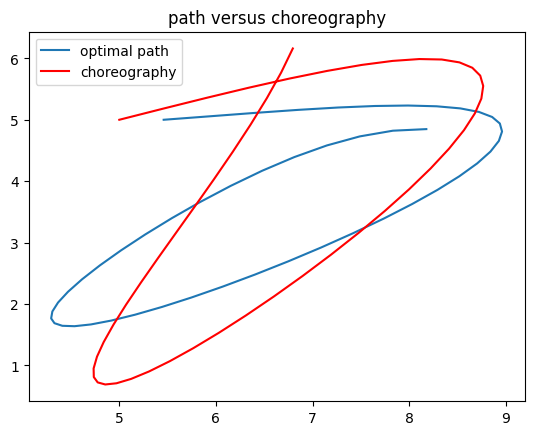

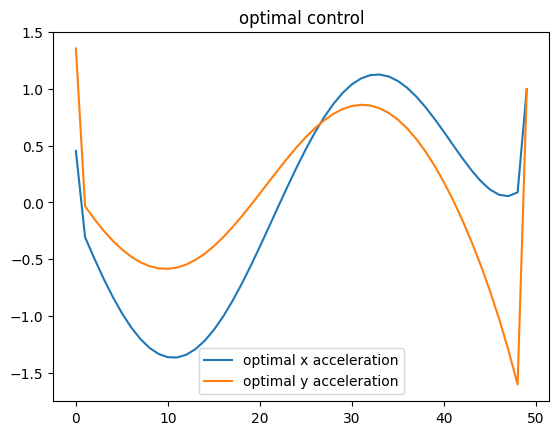

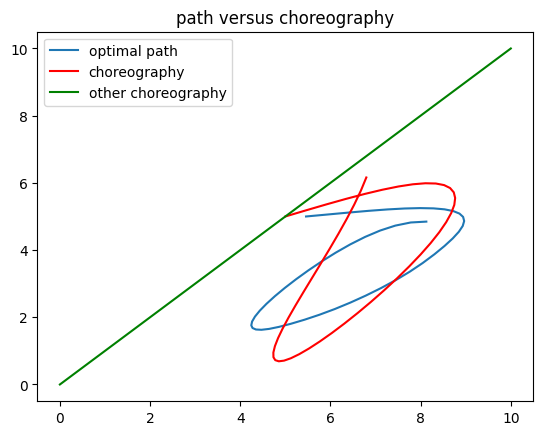

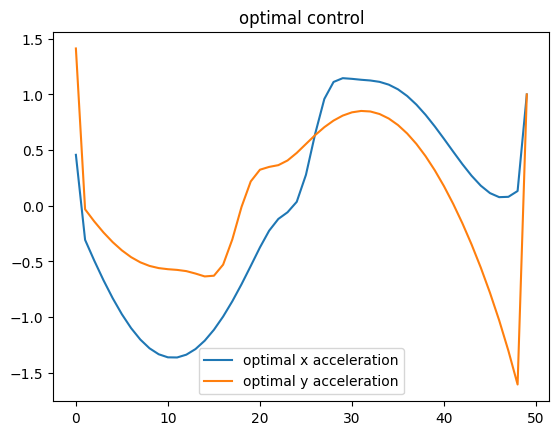

In [17]:
# one couple complex
tf = 10
t_steps = 50
choreography1 = curliques(a=0.5, b=0.2)
choreography2 = straight_line((0, 0), (10, 10), tf)

optimal_u, optimal_path = simulation(choreography1, tf, t_steps, filename1="onecouplecomplexpath.jpg", filename2="onecouplecomplexu.jpg")
optimal_u, optimal_path = simulation(choreography1, tf, t_steps, filename1="twocouplecomplexpath.jpg", filename2="twocouplecomplexu.jpg", other_choreography=choreography2)
# animate_optimal_control(choreography1, tf, t_steps, "complex_choreo.mp4", optimal_u, optimal_path, other_choreography=choreography2)
# Video("complex_choreo.mp4", width=640, embed=True)
# show_choreo(choreography1)

In [ ]:
# one couple complex choreo
cc1 = curliques(a=3.0, b=2.0)   # clean 3-petal rose
cc2 = curliques(a=2.3, b=1.7)   # dense curlicues (irrational-ish ratio)
cc3 = curliques(a=4.1, b=2.9)   # tight overlapping spirals
cc4 = curliques(a=3.7, b=1.3)   # asymmetric loopy fill

choreography1 = circle((3, 3), 3)
tf = 10
t_steps = 100
# optimal_u, optimal_path = simulation(cc3, tf, t_steps, other_choreography=choreography1)

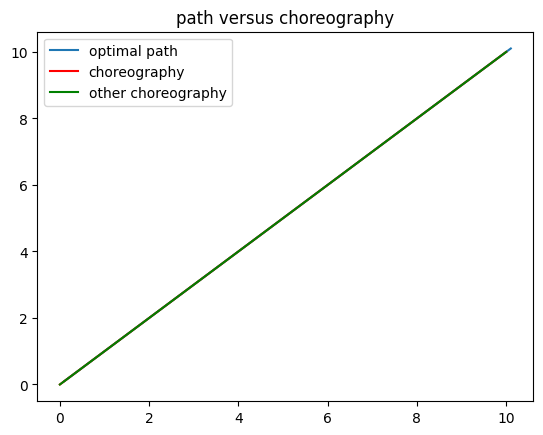

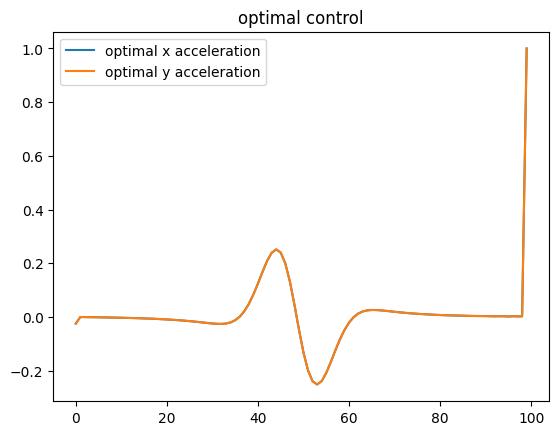

In [14]:
# couples running into each other on the same path
choreography1 = straight_line((0, 0), (10, 10), tf)
choreography2 = straight_line((10, 10), (0, 0), tf)
tf = 10
t_steps = 100
optimal_u, optimal_path = simulation(choreography1, tf, t_steps, filename1="collisionpath.jpg", filename2="collisionu.jpg", other_choreography=choreography2)